In [4]:
from torchvision import datasets, models, transforms
import torch.optim as optim
from torch.utils.data import DataLoader
import time
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch.nn as nn
import torch.nn.functional as F


c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
#train and test data directory
data_dir = train_data_dir = r"B:\Python_projects\Skin Cancer\New_data\data_final_tr" 
val_data_dir = r"B:\Python_projects\Skin Cancer\New_data\data_final_val"
test_data_dir = r"B:\Python_projects\Skin Cancer\New_data\data_final_test"
# test_data_dir = "../input/intel-image-classification/seg_test/seg_test"


#load the train 
train_transform = ImageFolder(train_data_dir ,transform = T.Compose([
    T.RandomRotation(10),
     # T.RandomAffine(0, translate=(0.1, 0.1)),
    T.RandomHorizontalFlip(),
    # T.RandomVerticalFlip(),
    # T.RandomApply(torch.nn.ModuleList([T.ColorJitter()]), p=0.5),
    T.Resize((224, 224)),
#     T.CenterCrop(224),
    T.RandomApply([T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))], p=0.5),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]))


#load the val 
val_transform = ImageFolder(val_data_dir,transform = T.Compose([
    T.RandomRotation(10),
     # T.RandomAffine(0, translate=(0.1, 0.1)),
    T.RandomHorizontalFlip(),
    # T.RandomVerticalFlip(),
    # T.RandomApply(torch.nn.ModuleList([T.ColorJitter()]), p=0.5),
    T.Resize((224, 224)),
#     T.CenterCrop(224),
    T.RandomApply([T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))], p=0.5),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]))


#load the val 
test_transform = ImageFolder(test_data_dir,transform = T.Compose([
    T.RandomRotation(10),
     # T.RandomAffine(0, translate=(0.1, 0.1)),
    T.RandomHorizontalFlip(),
    # T.RandomVerticalFlip(),
    # T.RandomApply(torch.nn.ModuleList([T.ColorJitter()]), p=0.5),
    T.Resize((224, 224)),
#     T.CenterCrop(224),
    T.RandomApply([T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))], p=0.5),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
]))



In [23]:
print("Follwing classes are there : \n",train_transform.classes)


Follwing classes are there : 
 ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label : AKIEC


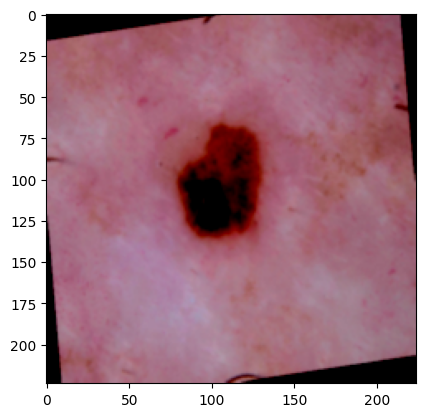

In [12]:
def display_img(img,label):
    print(f"Label : {train_transform.classes[label]}")
    plt.imshow(img.permute(1,2,0))

#display the first image in the dataset
display_img(*train_transform[2])

In [13]:
# from torch.utils.data.dataloader import DataLoader
# from torch.utils.data import random_split

# batch_size = 32
# val_size = 2980
# train_size = len(train_transform) - val_size 

# train_data,val_data = random_split(train_transform,[train_size,val_size])
# print(f"Length of Train Data : {len(train_data)}")
# print(f"Length of Validation Data : {len(val_data)}")

# #output
# #Length of Train Data : 12034
# #Length of Validation Data : 2000

# #load the train and validation into batches.
# train_dl = DataLoader(train_data, batch_size, shuffle = True, num_workers = 0, pin_memory = True)
# val_dl = DataLoader(val_data, batch_size, num_workers = 4, pin_memory = True)

In [24]:
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

batch_size = 32

train_data=train_transform
val_data=val_transform
test_data=test_transform


#load the train and validation into batches.
train_dl = DataLoader(train_data, batch_size, shuffle = True, num_workers = 0, pin_memory = True)
val_dl = DataLoader(val_data, batch_size, num_workers = 4, pin_memory = True)
test_dl = DataLoader(test_data, batch_size, num_workers = 4, pin_memory = True)



In [25]:
len(train_dl), len(val_dl)


(219, 63)

## RESNET

In [16]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

In [18]:
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet50(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(train_transform.classes))
    
    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

model = ResNet()

c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [12]:
device = get_default_device()
device

device(type='cuda')

In [13]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

In [14]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        num_batches = len(train_loader)
        
        # Initialize tqdm progress bar for the training loop
        with tqdm(total=num_batches, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for batch in train_loader:
                loss = model.training_step(batch)
                train_losses.append(loss)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                
                # Update the progress bar by one batch
                pbar.update(1)
        
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    
    return history


In [15]:
resnet = to_device(ResNet(), device)



In [16]:
num_epochs = 10
opt_func = torch.optim.Adam
lr = .0002

history = fit(num_epochs, lr, resnet, train_dl, val_dl, opt_func)

Epoch 1/10: 100%|██████████| 157/157 [00:37<00:00,  4.19batch/s]


Epoch 1: train_loss: 1.4131, val_loss: 1.3778, val_acc: 0.7550


Epoch 2/10: 100%|██████████| 157/157 [00:37<00:00,  4.24batch/s]


Epoch 2: train_loss: 1.3716, val_loss: 1.3698, val_acc: 0.7626


Epoch 3/10: 100%|██████████| 157/157 [00:36<00:00,  4.28batch/s]


...

Epoch 8: train_loss: 1.3310, val_loss: 1.3476, val_acc: 0.7922


Epoch 9/10: 100%|██████████| 157/157 [00:37<00:00,  4.24batch/s]


Epoch 9: train_loss: 1.3229, val_loss: 1.3407, val_acc: 0.7945


Epoch 10/10: 100%|██████████| 157/157 [00:36<00:00,  4.25batch/s]


Epoch 10: train_loss: 1.3211, val_loss: 1.3455, val_acc: 0.7809


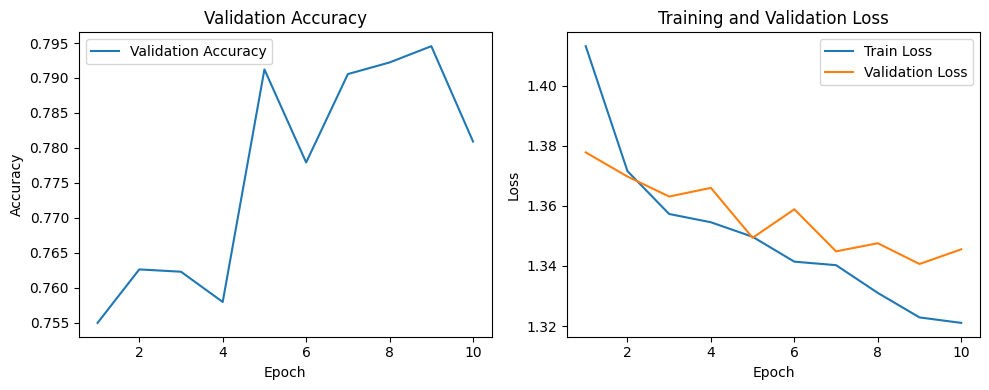

In [17]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Extract the training/validation accuracy and loss from the history
    # train_accuracy = [entry['train_accuracy'] for entry in history]
    val_accuracy = [entry['val_acc'] for entry in history]
    train_loss = [entry['train_loss'] for entry in history]
    val_loss = [entry['val_loss'] for entry in history]

    # Plot accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    epochs = range(1, len(val_accuracy) + 1)
    # plt.plot(epochs, train_accuracy, label='Train Accuracy')
    plt.plot(epochs, val_accuracy, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()
plot_history(history)

In [18]:
# torch.save(resnet.state_dict(), 'resnet.pt')



In [19]:
resnet = ResNet()
resnet.load_state_dict(torch.load('resnet.pt'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet.to(device)
# Set the model to evaluation mode
resnet.eval()

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

In [27]:
# Create empty lists to store predictions and targets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
predicted_labels1 = []
true_labels1= []

resnet.eval()  # Set the model to evaluation mode

for data, target in tqdm(val_dl):
    data, target = data.to(device), target.to(device)
    with torch.no_grad():  # Turn off gradient computation
        output = resnet(data)
        _, predictions = torch.max(output, 1)
    
    # Convert tensors to numpy arrays
    predictions = predictions.cpu().numpy()
    targets = target.cpu().numpy()

    # Append predictions and targets to the lists
    predicted_labels1.extend(predictions)
    true_labels1.extend(targets)
# Calculate accuracy
accuracy = accuracy_score(true_labels1, predicted_labels1)

# Calculate precision, recall, and F1-score for multiclass classification
precision = precision_score(true_labels1, predicted_labels1, average='macro')
recall = recall_score(true_labels1, predicted_labels1, average='macro')
f1 = f1_score(true_labels1, predicted_labels1, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

100%|██████████| 63/63 [00:21<00:00,  2.88it/s]

Accuracy: 0.76
Precision: 0.43058658043424813
Recall: 0.47275034076202377
F1-score: 0.442479257323065



c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# Create empty lists to store predictions and targets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
predicted_labels1 = []
true_labels1= []

resnet.eval()  # Set the model to evaluation mode

for data, target in tqdm(test_dl):
    data, target = data.to(device), target.to(device)
    with torch.no_grad():  # Turn off gradient computation
        output = resnet(data)
        _, predictions = torch.max(output, 1)
    
    # Convert tensors to numpy arrays
    predictions = predictions.cpu().numpy()
    targets = target.cpu().numpy()

    # Append predictions and targets to the lists
    predicted_labels1.extend(predictions)
    true_labels1.extend(targets)
# Calculate accuracy
accuracy = accuracy_score(true_labels1, predicted_labels1)

# Calculate precision, recall, and F1-score for multiclass classification
precision = precision_score(true_labels1, predicted_labels1, average='macro')
recall = recall_score(true_labels1, predicted_labels1, average='macro')
f1 = f1_score(true_labels1, predicted_labels1, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

100%|██████████| 32/32 [00:10<00:00,  2.96it/s]

Accuracy: 0.6620689655172414
Precision: 0.34990185517186223
Recall: 0.41953645427588043
F1-score: 0.36656504934197603



c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Densenet

In [21]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

In [22]:
class DenseNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.densenet121(pretrained= True)
        # Replace last layer
        num_ftrs = self.network.classifier.in_features
        self.network.classifier = nn.Linear(num_ftrs, len(dataset.classes))
    
    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

densenet = DenseNet()

c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Haider\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(densenet, device)

DenseNet(
  (network): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.

In [24]:
densenet = to_device(DenseNet(), device)


In [25]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        # Initialize the progress bar for the training phase
        num_batches = len(train_loader)
        with tqdm(total=num_batches, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for batch in train_loader:
                loss = model.training_step(batch)
                train_losses.append(loss)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                pbar.update(1)  # Update the progress bar by one batch
        
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history


In [26]:
# num_epochs = 20
# opt_func = torch.optim.Adam
# lr = 0.0002

# history = fit(num_epochs, lr, densenet, train_dl, val_dl, opt_func)

In [27]:
# torch.save(densenet.state_dict(), 'densenet.pt')


In [28]:
# import matplotlib.pyplot as plt

# def plot_history(history):
#     # Extract the training/validation accuracy and loss from the history
#     # train_accuracy = [entry['train_accuracy'] for entry in history]
#     val_accuracy = [entry['val_acc'] for entry in history]
#     train_loss = [entry['train_loss'] for entry in history]
#     val_loss = [entry['val_loss'] for entry in history]

#     # Plot accuracy
#     plt.figure(figsize=(10, 4))
#     plt.subplot(1, 2, 1)
#     epochs = range(1, len(val_accuracy) + 1)
#     # plt.plot(epochs, train_accuracy, label='Train Accuracy')
#     plt.plot(epochs, val_accuracy, label='Validation Accuracy')
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy')
#     plt.title('Validation Accuracy')
#     plt.legend()

#     # Plot loss
#     plt.subplot(1, 2, 2)
#     plt.plot(epochs, train_loss, label='Train Loss')
#     plt.plot(epochs, val_loss, label='Validation Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title('Training and Validation Loss')
#     plt.legend()

#     # Show the plot
#     plt.tight_layout()
#     plt.show()
# plot_history(history)

In [29]:
densenet = DenseNet()
densenet.load_state_dict(torch.load('densenet.pt'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
densenet.to(device)
# Set the model to evaluation mode
densenet.eval()

DenseNet(
  (network): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.

In [30]:
# Create empty lists to store predictions and targets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
predicted_labels2 = []
true_labels2= []

densenet.eval()  # Set the model to evaluation mode

for data, target in tqdm(val_dl):
    data, target = data.to(device), target.to(device)
    with torch.no_grad():  # Turn off gradient computation
        output = densenet(data)
        _, predictions = torch.max(output, 1)
    
    # Convert tensors to numpy arrays
    predictions = predictions.cpu().numpy()
    targets = target.cpu().numpy()

    # Append predictions and targets to the lists
    predicted_labels2.extend(predictions)
    true_labels2.extend(targets)
# Calculate accuracy
accuracy = accuracy_score(true_labels2, predicted_labels2)

# Calculate precision, recall, and F1-score for multiclass classification
precision = precision_score(true_labels2, predicted_labels2, average='macro')
recall = recall_score(true_labels2, predicted_labels2, average='macro')
f1 = f1_score(true_labels2, predicted_labels2, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

100%|██████████| 94/94 [00:15<00:00,  6.14it/s]

Accuracy: 0.9204697986577182
Precision: 0.8891515789595636
Recall: 0.7749977588980889
F1-score: 0.8200942356209309


## Custom_CNN


In [31]:
import torch.nn as nn
import torch.nn.functional as F
import torch.nn as nn
import torch.nn.functional as F

class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch):
        images, labels = batch 
        images = images.to(device)  # Move input data to GPU
        labels = labels.to(device)  # Move input data to GPU
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        images = images.to(device)  # Move input data to GPU
        labels = labels.to(device)  # Move input data to GPU
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))
        
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [32]:
class Classification(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32,64, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        
            nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(128 ,128, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            # nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1),
            # nn.ReLU(),
            # nn.Conv2d(256,256, kernel_size = 3, stride = 1, padding = 1),
            # nn.ReLU(),
            # nn.MaxPool2d(2,2),
            
            nn.Flatten(),
            nn.Linear(128*56*56,128),
            nn.ReLU(),
            # nn.Linear(512, 128),
            # nn.ReLU(),
            nn.Linear(128,7)
        )
    
    def forward(self, xb):
        return self.network(xb)

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CNN = Classification()
CNN.to(device)

Classification(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=401408, out_features=128, bias=True)
    (12): ReLU()
    (13): Linear(in_features=128, out_features=7, bias=True)
  )
)

In [34]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        
        model.train()
        train_losses = []
        # Initialize tqdm progress bar for the training loop
        num_batches = len(train_loader)
        with tqdm(total=num_batches, desc=f"Epoch {epoch+1}/{epochs}", unit="batch") as pbar:
            for batch in train_loader:
                loss = model.training_step(batch)
                train_losses.append(loss)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                pbar.update(1)  # Update the progress bar by one batch

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    
    return history


In [35]:


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# num_epochs = 10
# opt_func = torch.optim.Adam
# lr = 0.0002

# history = fit(num_epochs, lr, CNN, train_dl, val_dl, opt_func)

In [36]:
# torch.save(CNN.state_dict(), 'Cnn.pt')


In [37]:
# import matplotlib.pyplot as plt

# def plot_history(history):
#     # Extract the training/validation accuracy and loss from the history
#     # train_accuracy = [entry['train_accuracy'] for entry in history]
#     val_accuracy = [entry['val_acc'] for entry in history]
#     train_loss = [entry['train_loss'] for entry in history]
#     val_loss = [entry['val_loss'] for entry in history]

#     # Plot accuracy
#     plt.figure(figsize=(10, 4))
#     plt.subplot(1, 2, 1)
#     epochs = range(1, len(val_accuracy) + 1)
#     # plt.plot(epochs, train_accuracy, label='Train Accuracy')
#     plt.plot(epochs, val_accuracy, label='Validation Accuracy')
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy')
#     plt.title('Validation Accuracy')
#     plt.legend()

#     # Plot loss
#     plt.subplot(1, 2, 2)
#     plt.plot(epochs, train_loss, label='Train Loss')
#     plt.plot(epochs, val_loss, label='Validation Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title('Training and Validation Loss')
#     plt.legend()

#     # Show the plot
#     plt.tight_layout()
#     plt.show()
# plot_history(history)

In [38]:
model2 = Classification()
model2.load_state_dict(torch.load('Cnn.pt'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)
# Set the model to evaluation mode
model2.eval()

Classification(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=401408, out_features=128, bias=True)
    (12): ReLU()
    (13): Linear(in_features=128, out_features=7, bias=True)
  )
)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
predicted_labels3= []
true_labels3= []

model2.eval()  # Set the model to evaluation mode

for data, target in tqdm(val_dl):
    data, target = data.to(device), target.to(device)
    with torch.no_grad():  # Turn off gradient computation
        output = model2(data)
        _, predictions = torch.max(output, 1)
    
    # Convert tensors to numpy arrays
    predictions = predictions.cpu().numpy()
    targets = target.cpu().numpy()

    # Append predictions and targets to the lists
    predicted_labels3.extend(predictions)
    true_labels3.extend(targets)
# Calculate precision, recall, and F1-score for multiclass classification
precision = precision_score(true_labels3, predicted_labels3, average='macro')
recall = recall_score(true_labels3, predicted_labels3, average='macro')
f1 = f1_score(true_labels3, predicted_labels3, average='macro')


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

100%|██████████| 94/94 [00:14<00:00,  6.45it/s]

Accuracy: <function accuracy at 0x0000020329EC77E0>
Precision: 0.7607291568712141
Recall: 0.5370730161036226
F1-score: 0.563937356866943
